In [1]:
from pathlib import Path
from collections import defaultdict
import numpy as np
from notebooks.utils.training_results import TrainingResults, TrainingResultsList

model_names = ['rgfn_is_decomposable', 'rgfn_cost_biasing', 'rgfn_expl_bias']
model_map = {
    'rgfn_is_decomposable': 'SCENT (w/o C)',
    'rgfn_cost_biasing': 'SCENT (C)',
    'rgfn_expl_bias': 'SCENT (C+P)',
}
sizes = [2, 4, 8, 16, 32, 64, 128]


results_dict = defaultdict(list)

for model_name in model_names:
    for bb_size in sizes:
        results_list = []
        templates_name = 'synflow_2_128' if bb_size == 128 else f'synflow_{bb_size}'
        seeds = [0, 3] if (model_name == 'rgfn_expl_bias' and templates_name == 'synflow_256') else list(range(3))
        seeds = [1, 2] if (model_name == 'rgfn_is_decomposable' and templates_name == 'synflow_256') else seeds
        for seed in seeds:
            try:
                result = TrainingResults(
                    model_name=model_name,
                    templates_name=f'synflow_{bb_size}',
                    seed=seed,
                    task_name='seh',
                    threshold=8.0,
                    results_dir=Path('../results'),
                )
                results_list.append(result)
            except FileNotFoundError as e:
                print(f'File not found: {e}')
        training_result_list = TrainingResultsList(results_list)
        results_dict[model_name].append(training_result_list)

/Users/piotrgainski/miniconda3/envs/rgfn/lib/python3.11/site-packages/torch_geometric/typing.py:54: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: dlopen(/Users/piotrgainski/miniconda3/envs/rgfn/lib/python3.11/site-packages/libpyg.so, 0x0006): Library not loaded: /Library/Frameworks/Python.framework/Versions/3.11/Python
  Referenced from: <75FFC412-93B5-322B-8E6D-268DA3498CF4> /Users/piotrgainski/miniconda3/envs/rgfn/lib/python3.11/site-packages/libpyg.so
  Reason: tried: '/Library/Frameworks/Python.framework/Versions/3.11/Python' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/Python.framework/Versions/3.11/Python' (no such file), '/Library/Frameworks/Python.framework/Versions/3.11/Python' (no such file)
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/Users/piotrgainski/miniconda3/envs/rgfn/lib/python3.11/site-packages/torch_geometric/typing.py:110: UserWarning: An issue occurred while importing 'to

rgfn_is_decomposable modes 316.3333333333333
rgfn_cost_biasing modes 290.3333333333333
rgfn_expl_bias modes 361.6666666666667
rgfn_is_decomposable scaffolds 3341.3333333333335
rgfn_cost_biasing scaffolds 4818.0
rgfn_expl_bias scaffolds 8443.333333333334


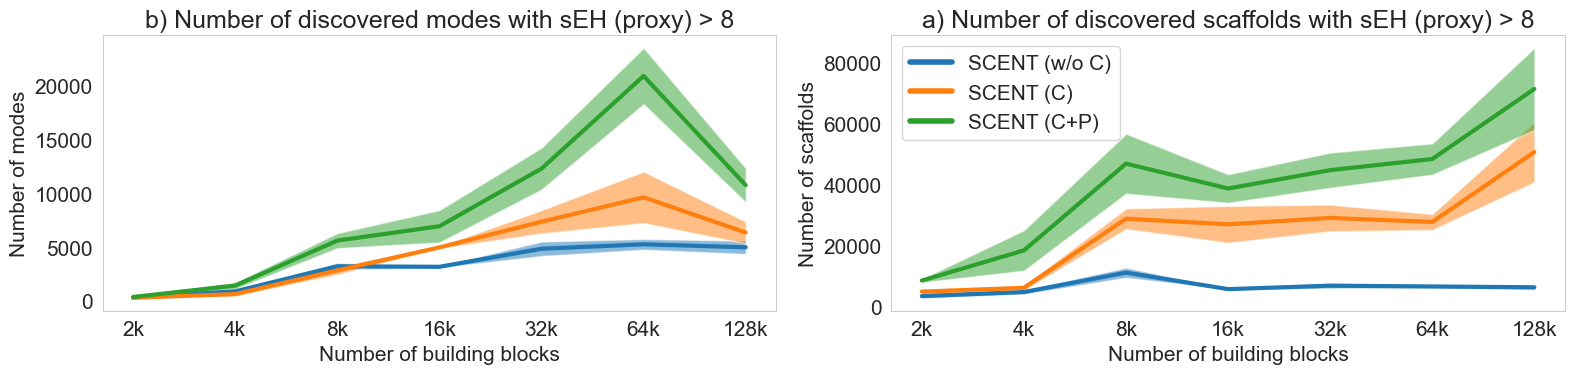

In [2]:
import json
# plot number of scaffolds
import matplotlib
matplotlib.rcParams.update({'font.size': 15})

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
plot_dict = defaultdict(dict)
def plot_stuff(results_dict, metric_name):
    for model_name, results_list in results_dict.items():
        # print(model_name)
        if metric_name == 'modes':
            mean_std_list = [results_list.get_num_modes_mean_std(2) for results_list in results_list]
        elif metric_name == 'scaffolds':
            mean_std_list = [results_list.get_num_scaffolds_mean_std(3000 * 64) for results_list in results_list]
        else:
            raise ValueError(f'Unknown metric name: {metric_name}')
        print(model_name, metric_name, mean_std_list[0][0])
        mean_list, std_list = zip(*mean_std_list)
        plot_dict[model_map[model_name]][metric_name] = {'mean': mean_list, 'std': std_list}
        mean_numpy, std_numpy = np.array(mean_list), np.array(std_list)
        plt.plot(sizes, mean_numpy, label=model_map[model_name], linewidth=3)
        plt.fill_between(sizes, mean_numpy - std_numpy, mean_numpy + std_numpy, alpha=0.5)

    plt.xscale('log')
    plt.xlabel('Number of building blocks')
    plt.ylabel(f'Number of {metric_name}')
    plt.xticks(ticks=sizes, labels=[f'{s}k' for s in sizes])

metrics = ['modes', 'scaffolds']

# plt.figure(figsize=(8, 4*len(metrics)))
plt.figure(figsize=(8*len(metrics), 4))
for i, metric in enumerate(metrics, 1):
    # plt.subplot(len(metrics), 1, i)
    plt.subplot(1, len(metrics), i)
    plot_stuff(results_dict, metric)
    prefix = ""
    if len(metrics) == 2 or True:
        prefix = "a) " if metric == 'scaffolds' else "b) "
    plt.title(f'{prefix}Number of discovered {metric} with sEH (proxy) > 8')
    plt.grid(False)

leg = plt.legend()
for line in leg.get_lines():
    line.set_linewidth(4.0)
plt.tight_layout()

plt.savefig(f'outputs/scaling_{"_".join(metrics)}.pdf', bbox_inches='tight')

json.dump(plot_dict, open('plotting_data/figure_6.json', 'w'), indent=4)

plt.show()